In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Gradient-Based Optimization

Every neural network is moved by some descendant of gradient descent. Before the
main book hands you the optimizer zoo (momentum, RMSProp, Adam, learning-rate
schedules), this section explains the foundations underneath all of them: *why* a
negative-gradient step makes progress, *how fast* it converges, and *what breaks
it*. One number recurs throughout: the **condition number** $\kappa$, read off
the Hessian's spectrum, which predicts whether gradient descent glides to
the minimum or grinds along an ill-conditioned valley. We develop the deterministic
theory on quadratics (where everything is computable in closed form), then add the
two ingredients that make it practical at scale, momentum and stochasticity,
and close with a short look at second-order methods to explain why we *don't* use
them.

We lean on that section (gradients, directional
derivatives, the Hessian and the second-order Taylor expansion),
that section (the one-dimensional descent lemma
and Newton's method, both of which we now grow to $n$ dimensions), and
that section together with that section
(eigenvalues and the condition number
$\kappa = \lambda_{\max}/\lambda_{\min}$). Convexity is *forward*-referenced:
the two global convergence theorems whose proofs need it, and the equivalent
readings of strong convexity quoted alongside them, are stated here and
proved in that section. Standard references are
@Boyd.Vandenberghe.2004, @Nesterov.2018, and chapters 4 and 8 of
@Goodfellow.Bengio.Courville.2016 . As in the rest of this chapter, the
code is plain NumPy, because every algorithm
is a handful of lines; we load the `d2l` module once for plotting.

In [1]:
%matplotlib inline
from d2l import jax as d2l
import numpy as np

## Descent Directions

Optimization begins with a single question: standing at a point $\mathbf{x}$,
in which direction should we move? The multivariable calculus of
that section supplies the local model. For a
differentiable $f : \mathbb{R}^n \to \mathbb{R}$, a small step of size
$\eta > 0$ along a direction $\mathbf{d}$ changes the value by

$$
f(\mathbf{x} + \eta\,\mathbf{d}) = f(\mathbf{x}) + \eta\, \nabla f(\mathbf{x})^\top \mathbf{d} + o(\eta),
$$

so to first order the *only* thing that matters about $\mathbf{d}$ is the
directional derivative $\nabla f(\mathbf{x})^\top \mathbf{d}$. Call $\mathbf{d}$
a **descent direction** at $\mathbf{x}$ if $\nabla f(\mathbf{x})^\top \mathbf{d} < 0$.
A negative slope in the model forces a genuine decrease of
$f$ for all sufficiently small steps, and among all unit directions there is a
unique steepest one.

**Proposition (descent directions, and the steepest one).** *Let $f$ be
differentiable at $\mathbf{x}$ with $\nabla f(\mathbf{x}) \neq \mathbf{0}$.*

1. *If $\nabla f(\mathbf{x})^\top \mathbf{d} < 0$, then
   $f(\mathbf{x} + \eta\,\mathbf{d}) < f(\mathbf{x})$ for every sufficiently
   small $\eta > 0$.*
2. *Among unit vectors, the directional derivative is minimized uniquely by the
   normalized negative gradient:*

$$
\min_{\|\mathbf{d}\| = 1} \nabla f(\mathbf{x})^\top \mathbf{d} = -\|\nabla f(\mathbf{x})\|,
\qquad \textrm{attained only at } \mathbf{d} = -\frac{\nabla f(\mathbf{x})}{\|\nabla f(\mathbf{x})\|}.
$$

**Proof.** For the first claim, the function
$\varphi(\eta) = f(\mathbf{x} + \eta\,\mathbf{d})$ has
$\varphi'(0) = \nabla f(\mathbf{x})^\top \mathbf{d} < 0$ by the chain rule, so
the difference quotient $(\varphi(\eta) - \varphi(0))/\eta$ is negative for all
small $\eta > 0$, i.e. $\varphi(\eta) < \varphi(0)$. The second claim is the
steepest-descent proposition proved by Cauchy--Schwarz in
that section.
$\blacksquare$

Statement 2 is *why* gradient descent follows
$-\nabla f$: a theorem rather than a definition. But notice how *weak* the
requirement for progress is. Descent directions form an entire open half-space
(everything within $90^\circ$ of $-\nabla f$), and the family
$\mathbf{d} = -B\,\nabla f(\mathbf{x})$ for *any* positive-definite matrix $B$
consists of nothing but descent directions (Exercise 2). Newton's method and
every preconditioned optimizer live inside this family, choosing $B$ to encode
curvature; we return to them in that section. The cell
below makes the proposition concrete on the running example of this section,
$f(x, y) = \tfrac12(x^2 + 10\,y^2)$: it compares the first-order slope and the
actual decrease along several unit directions, then scans $3600$ directions to
confirm that the most negative slope sits exactly at $-\nabla f / \|\nabla f\|$.

In [2]:
def f(v):
    return 0.5 * (v[0]**2 + 10 * v[1]**2)

def grad(v):
    return np.array([v[0], 10 * v[1]])

x = np.array([2.0, 1.0])
g = grad(x)
steepest = -g / np.linalg.norm(g)
candidates = [('steepest -grad/|grad|', steepest),
              ('diagonal -(1,1)/sqrt(2)', -np.ones(2) / np.sqrt(2)),
              ('axis     (-1,0)', np.array([-1.0, 0.0])),
              ('uphill   +(1,1)/sqrt(2)', np.ones(2) / np.sqrt(2))]
eta = 0.01
for name, d in candidates:
    print(f'{name}:  slope = {g @ d:+8.4f},  '
          f'f(x + eta d) - f(x) = {f(x + eta * d) - f(x):+.6f}')
thetas = np.linspace(0.0, 2 * np.pi, 3601)
dirs = np.stack([np.cos(thetas), np.sin(thetas)])
best = dirs[:, np.argmin(g @ dirs)]
print('best of 3600 sampled unit directions:', best.round(4),
      ' vs  -grad/|grad| =', steepest.round(4))

steepest -grad/|grad|:  slope = -10.1980,  f(x + eta d) - f(x) = -0.101498
diagonal -(1,1)/sqrt(2):  slope =  -8.4853,  f(x + eta d) - f(x) = -0.084578
axis     (-1,0):  slope =  -2.0000,  f(x + eta d) - f(x) = -0.019950
uphill   +(1,1)/sqrt(2):  slope =  +8.4853,  f(x + eta d) - f(x) = +0.085128
best of 3600 sampled unit directions: [-0.1959 -0.9806]  vs  -grad/|grad| = [-0.1961 -0.9806]


Every direction with a negative slope really does lower $f$ (even the lazy
axis direction, whose slope $-2.0$ is five times weaker than the steepest
$-10.198$), and the brute-force scan over the unit circle lands on
$(-0.196, -0.981)$, the normalized negative gradient, to the resolution of the
grid. One foreshadowing remark: "steepest" is a *local* superlative. The
greediest direction at each point is not necessarily the fastest *route* over
many steps: on the elongated valleys we are about to meet, pure steepest
descent zig-zags, and a little inertia (momentum,
that section) will beat it soundly.

## Gradient Descent and Smoothness

### The Iteration and the Smoothness Assumption

**Gradient descent** iterates the steepest step with a fixed **step size**
(learning rate) $\eta > 0$:

$$
\mathbf{x}_{k+1} = \mathbf{x}_k - \eta\, \nabla f(\mathbf{x}_k).
$$

The first-order model justified the *direction*; it says nothing about how
*far* to trust that direction. The slope we measured at $\mathbf{x}_k$ goes
stale as we move, and the hypothesis we add is a bound on how fast it
can go stale. We say $f$ is **$L$-smooth** if its gradient is $L$-Lipschitz,

$$
\|\nabla f(\mathbf{x}) - \nabla f(\mathbf{y})\| \;\le\; L\, \|\mathbf{x} - \mathbf{y}\|
\qquad \textrm{for all } \mathbf{x}, \mathbf{y},
$$

which for twice-differentiable $f$ is equivalent to every Hessian
eigenvalue lying in $[-L, L]$: bounded eigenvalues give
the equation by integrating the Hessian along the segment
from $\mathbf{x}$ to $\mathbf{y}$ (the same device as in the proof below),
and the converse is a mean-value argument we leave to the reader. Either way,
the curvature is bounded by $L$ in every
direction. Smoothness converts the first-order model into a one-sided
*guarantee*: a quadratic ceiling

$$
f(\mathbf{y}) \;\le\; f(\mathbf{x}) + \nabla f(\mathbf{x})^\top (\mathbf{y} - \mathbf{x}) + \tfrac{L}{2}\, \|\mathbf{y} - \mathbf{x}\|^2
$$

erected over the graph, touching it at $\mathbf{x}$. The one-dimensional
version of this ceiling (and the picture that makes the next proof obvious)
is the figure in
that section: whatever $f$ does underneath,
stepping to the ceiling's minimizer must lower $f$ by at least as much as it
lowers the ceiling.

### The Descent Lemma

**Proposition (descent lemma).** *If $f$ is $L$-smooth, then the gradient step
the equation satisfies*

$$
f(\mathbf{x}_{k+1}) \;\le\; f(\mathbf{x}_k) - \eta \left(1 - \tfrac{L\eta}{2}\right) \|\nabla f(\mathbf{x}_k)\|^2.
$$

*In particular $f$ strictly decreases whenever $0 < \eta < 2/L$ and
$\nabla f(\mathbf{x}_k) \neq \mathbf{0}$, and the guaranteed decrease is
largest at $\eta = 1/L$, where it reads
$f(\mathbf{x}_{k+1}) \le f(\mathbf{x}_k) - \tfrac{1}{2L}\|\nabla f(\mathbf{x}_k)\|^2$.*

**Proof.** First the ceiling the equation. Restrict
$f$ to the segment, $g(t) = f(\mathbf{x} + t(\mathbf{y} - \mathbf{x}))$ for
$t \in [0, 1]$, so that
$g'(t) = \nabla f(\mathbf{x} + t(\mathbf{y}-\mathbf{x}))^\top (\mathbf{y} - \mathbf{x})$.
By the fundamental theorem of calculus and then Cauchy--Schwarz with the
Lipschitz bound the equation,

$$
f(\mathbf{y}) - f(\mathbf{x}) - \nabla f(\mathbf{x})^\top (\mathbf{y}-\mathbf{x})
= \int_0^1 \big(\nabla f(\mathbf{x} + t(\mathbf{y}-\mathbf{x})) - \nabla f(\mathbf{x})\big)^\top (\mathbf{y}-\mathbf{x})\, dt
\;\le\; \int_0^1 L\,t\, \|\mathbf{y}-\mathbf{x}\|^2\, dt = \tfrac{L}{2}\|\mathbf{y}-\mathbf{x}\|^2,
$$

which is the same one-line argument as the 1-D proof in
that section, run along the segment. Now insert
the gradient step
$\mathbf{y} = \mathbf{x}_k - \eta \nabla f(\mathbf{x}_k)$:

$$
f(\mathbf{x}_{k+1}) \;\le\; f(\mathbf{x}_k) - \eta\,\|\nabla f(\mathbf{x}_k)\|^2 + \tfrac{L}{2}\,\eta^2\, \|\nabla f(\mathbf{x}_k)\|^2,
$$

and the bracket $\eta(1 - L\eta/2)$ is positive exactly for $\eta < 2/L$ and
maximized at $\eta = 1/L$. $\blacksquare$

Read the two terms as a ledger: the first-order model promises a gain of
$\eta\,\|\nabla f\|^2$, and curvature charges a tax of at most
$\tfrac{L}{2}\eta^2\,\|\nabla f\|^2$. The tax grows *quadratically* in $\eta$
while the gain grows linearly, so short steps are always profitable and the
break-even point is $\eta = 2/L$. Everything in this section, and every
learning-rate discussion in the main book, is some elaboration of this
ledger.

### Guarantees Without Convexity

The lemma alone, with no convexity, yields the standard smooth nonconvex
benchmark for neural-network optimization. It is an idealized model rather than
a theorem about every network: ReLU objectives are nonsmooth, and a useful
$L$-smooth bound may hold only locally or along a particular trajectory.

**Proposition (gradient descent finds approximate stationary points).** *Let
$f$ be $L$-smooth and bounded below by $f^\star$, and run
the equation with $\eta = 1/L$. Then for every $K \ge 1$,*

$$
\min_{0 \le k < K} \|\nabla f(\mathbf{x}_k)\|^2 \;\le\; \frac{2L\,\big(f(\mathbf{x}_0) - f^\star\big)}{K}.
$$

**Proof.** At $\eta = 1/L$ the descent lemma reads
$\|\nabla f(\mathbf{x}_k)\|^2 \le 2L\,(f(\mathbf{x}_k) - f(\mathbf{x}_{k+1}))$.
Sum over $k = 0, \ldots, K-1$; the right side telescopes to
$2L\,(f(\mathbf{x}_0) - f(\mathbf{x}_K)) \le 2L\,(f(\mathbf{x}_0) - f^\star)$.
The smallest of $K$ numbers is at most their average. $\blacksquare$

Within this smooth model the hypotheses are modest: a loss bounded below and a
finite smoothness constant on the region traversed by the iterates. No
convexity or unique minimum is required, and some iterate among the first $K$
has squared gradient norm $O(1/K)$. The result is a useful reference point for
neural-network training, but it guarantees a small gradient only when those
smoothness and step-size assumptions actually hold. What it does not promise is that
such a point is a *minimum*, let alone a global one: it could be a saddle
point (that section) or
a flat shelf. Upgrading "stationary" to "globally optimal" is precisely what
convexity buys, and the two theorems that do so are stated at the end of
that section and proved in
that section.

### Backtracking Line Search

The step $\eta = 1/L$ in the propositions above presumes we *know* $L$. We
rarely do; worse, the local curvature that matters varies across the
loss surface, so a single global constant is both unknown and too conservative. A
**line search** fixes this at runtime: try a step, and demand it achieve a
fixed fraction $c \in (0, 1)$ of the first-order promise, the **Armijo
condition** (also called sufficient decrease) [@Armijo.1966]

$$
f\big(\mathbf{x} - \eta\, \nabla f(\mathbf{x})\big) \;\le\; f(\mathbf{x}) - c\,\eta\, \|\nabla f(\mathbf{x})\|^2.
$$

**Backtracking** starts from an optimistic $\eta_0$ and halves $\eta$ until
the equation holds. By the descent lemma the condition is
automatic once $\eta \le 2(1-c)/L$, so the loop terminates after finitely many
halvings and always accepts a step
$\eta \ge \min\big(\eta_0,\, (1-c)/L\big)$: within a constant factor of the
ideal $1/L$, found without ever knowing $L$. The cell pits a fixed step against
backtracking on the quartic $f(x) = \tfrac14 x^4$, whose curvature
$f''(x) = 3x^2$ is brutal far from the origin and vanishing near it, so *no*
fixed step is right everywhere.

In [3]:
quartic = lambda v: 0.25 * (v ** 4).sum()
quartic_grad = lambda v: v ** 3

x = np.array([3.0])
for _ in range(6):                            # fixed step, too large at x0
    x = x - 0.3 * quartic_grad(x)
print(f'fixed eta = 0.3 from x0 = 3:  |x_6| = {abs(x[0]):.2e}  (diverged)')

x, etas = np.array([3.0]), []
for _ in range(25):                           # backtracking line search
    g = quartic_grad(x)
    eta = 1.0
    while quartic(x - eta * g) > quartic(x) - 0.5 * eta * (g * g).sum():
        eta *= 0.5                            # Armijo fails: halve the step
    x = x - eta * g
    etas.append(eta)
print('accepted steps:', np.array(etas[:8]), '...')
print(f'backtracking from x0 = 3:  f(x_25) = {quartic(x):.2e}  (monotone descent)')

fixed eta = 0.3 from x0 = 3:  |x_6| = 6.52e+103  (diverged)
accepted steps: [0.03125 0.0625  0.125   0.25    0.5     1.      1.      1.     ] ...
backtracking from x0 = 3:  f(x_25) = 1.09e-04  (monotone descent)


The fixed step $\eta = 0.3$ is fine near the minimum but fatal at the start: at
$x_0 = 3$ the local curvature is $f'' = 27$, the local stability ceiling is
$2/27 \approx 0.074$, and six steps later the iterate sits at
$|x_6| \approx 6.5 \times 10^{103}$. Backtracking, probing from $\eta_0 = 1$,
accepts $0.031$ on the first step (just under the local ceiling), then
doubles its acceptance as the valley flattens: $0.0625, 0.125, 0.25, 0.5, 1.0$.
The accepted step is tracking $2(1-c)/f''(x)$ automatically; a line search is
curvature estimation by trial. The reason you will not find one inside a deep
learning framework is cost: each probe is an extra evaluation of $f$, a full
forward pass over a batch, so practice replaces the search with engineered
learning-rate *schedules* (warmup, decay; that section and
onward).

## The Quadratic Model and the Condition Number

### Why Quadratics Tell the Truth

Near a minimum $\mathbf{x}^\star$, the second-order Taylor expansion of
that section says every smooth function *is* a
quadratic plus small change:
$f(\mathbf{x}) \approx f(\mathbf{x}^\star) + \tfrac12 (\mathbf{x}-\mathbf{x}^\star)^\top H\, (\mathbf{x}-\mathbf{x}^\star)$
with $H$ the Hessian at the minimum. So we study the model problem

$$
f(\mathbf{x}) = \tfrac12\, \mathbf{x}^\top A\, \mathbf{x},
\qquad A \textrm{ symmetric positive definite, eigenvalues }
0 < \lambda_{\min} = \lambda_1 \le \cdots \le \lambda_n = \lambda_{\max},
$$

for which gradient descent can be solved *exactly*, and the answer turns out
to be governed by a single scalar: the condition number
$\kappa = \lambda_{\max} / \lambda_{\min}$ from the introduction
(that section). Note that
$L = \lambda_{\max}$ here: the smoothness constant of a quadratic is its top
eigenvalue.

### Per-Mode Contraction and the 2/L Ceiling

The gradient is $\nabla f(\mathbf{x}) = A\mathbf{x}$, so the iteration
the equation is the fixed linear map

$$
\mathbf{x}_{k+1} = (I - \eta A)\, \mathbf{x}_k.
$$

Diagonalize: write $\mathbf{x}_k$ in the orthonormal eigenbasis of $A$
(that section) with coefficients $c_i^{(k)}$. Because
$I - \eta A$ has the same eigenvectors, the coordinates evolve *independently*:

$$
c_i^{(k+1)} = (1 - \eta \lambda_i)\, c_i^{(k)},
\qquad \textrm{hence} \qquad
c_i^{(k)} = (1 - \eta \lambda_i)^k\, c_i^{(0)}.
$$

Gradient descent on a quadratic is $n$ *uncoupled one-dimensional geometric
recursions*, one per curvature eigenvalue: one per "mode". Everything
follows from staring at the factors $1 - \eta\lambda_i$:

* **Convergence** requires $|1 - \eta \lambda_i| < 1$ for every mode, i.e.
  $0 < \eta < 2/\lambda_{\max} = 2/L$. This is the **stability ceiling**: the
  necessity, on quadratics, of the $2/L$ that the descent lemma offered as
  sufficiency. Past it, the stiffest mode's factor drops below $-1$ and that
  coordinate oscillates with *growing* amplitude while every other mode calmly
  converges: divergence along one axis (Exercise 4 has you build this
  half-converging, half-exploding run).
* **Speed** is set by the slowest mode: the error norm shrinks like
  $\rho(\eta)^k$, where $\rho(\eta) = \max_i |1 - \eta\lambda_i|$ is the
  **spectral radius** of the iteration matrix $I - \eta A$, its largest
  eigenvalue magnitude (that section); the sweep
  below prints it as its own column.

The cell sweeps $\eta$ across the ceiling on $A = \mathrm{diag}(1, 10)$, where
$L = 10$ and the ceiling sits at $\eta = 0.2$.

In [4]:
A = np.diag([1.0, 10.0])                      # eigenvalues 1 and 10, so L = 10
x0 = np.array([1.0, 1.0])

def run_gd(eta, steps=60):
    xs = [x0]
    for _ in range(steps):
        xs.append(xs[-1] - eta * (A @ xs[-1]))
    return np.array(xs)

print(' eta    |1-eta*1|  |1-eta*10|  spectral radius   |x_60|')
for eta in [0.02, 0.10, 2 / 11, 0.19, 0.20, 0.21]:
    f1, f10 = abs(1 - eta * 1.0), abs(1 - eta * 10.0)
    print(f'{eta:5.3f}    {f1:6.3f}     {f10:6.3f}        {max(f1, f10):6.3f}     '
          f'{np.linalg.norm(run_gd(eta)[-1]):9.1e}')

 eta    |1-eta*1|  |1-eta*10|  spectral radius   |x_60|
0.020     0.980      0.800         0.980       3.0e-01
0.100     0.900      0.000         0.900       1.8e-03
0.182     0.818      0.818         0.818       8.3e-06
0.190     0.810      0.900         0.900       1.8e-03
0.200     0.800      1.000         1.000       1.0e+00
0.210     0.790      1.100         1.100       3.0e+02


Each row of the table is one step-size regime. Tiny $\eta = 0.02$ is
stable but glacial ($\rho = 0.98$; after $60$ steps the error is still
$0.3$). At $\eta = 0.1$ the stiff mode is eliminated in one step (its factor
is exactly $0.000$) yet the *slow* mode now rules, $\rho = 0.9$. Note the
symmetry: $\eta = 0.19$ also has $\rho = 0.9$, but for the opposite reason:
its stiff mode oscillates with factor $-0.9$. Between them, $\eta = 2/11
\approx 0.182$ balances the two extremes and wins ($\rho = 0.818$, error
$8.3 \times 10^{-6}$). At the ceiling $\eta = 0.2$ the stiff mode's factor is
exactly $-1$: the iterate bounces between $\pm 1$ on that axis forever,
$\|\mathbf{x}_{60}\| = 1.0$. One tick above, $\eta = 0.21$, and sixty steps
inflate the error to $3 \times 10^{2}$.

### The Optimal Step and the $(\kappa-1)/(\kappa+1)$ Law

Within the stable range, which fixed $\eta$ is fastest? The sweep already
hinted at the answer: balance the two extreme modes.

**Proposition (optimal fixed step on a quadratic).** *For
$f(\mathbf{x}) = \tfrac12 \mathbf{x}^\top A \mathbf{x}$ the convergence factor
$\rho(\eta) = \max_i |1 - \eta\lambda_i|$ is minimized by*

$$
\eta^\star = \frac{2}{\lambda_{\min} + \lambda_{\max}},
\qquad
\rho(\eta^\star) = \frac{\kappa - 1}{\kappa + 1},
\qquad \kappa = \frac{\lambda_{\max}}{\lambda_{\min}}.
$$

**Proof.** For fixed $\eta > 0$, the function $\lambda \mapsto |1 - \eta\lambda|$
is a V with vertex at $\lambda = 1/\eta$: it decreases up to the vertex and
increases beyond it, so on the interval $[\lambda_{\min}, \lambda_{\max}]$ its
maximum sits at an endpoint:
$\rho(\eta) = \max\big(|1 - \eta\lambda_{\min}|,\, |1 - \eta\lambda_{\max}|\big)$.
As $\eta$ grows, the first term $1 - \eta\lambda_{\min}$ decreases while the
second, $\eta\lambda_{\max} - 1$ (once positive), increases, so the max of
the two is minimized where they are *equal*:
$1 - \eta\lambda_{\min} = \eta\lambda_{\max} - 1$, giving
$\eta^\star = 2/(\lambda_{\min} + \lambda_{\max})$ and
$\rho(\eta^\star) = (\lambda_{\max} - \lambda_{\min})/(\lambda_{\max} + \lambda_{\min}) = (\kappa-1)/(\kappa+1)$.
$\blacksquare$

the figure is this proof drawn on the running example:
each step size is a "tent" $|1 - \eta\lambda|$ with vertex at $\lambda = 1/\eta$,
the rate is the taller of the tent's two values over the extreme eigenvalues,
and the best tent is the one whose endpoints are level.

![The optimal-step proof in one picture: the per-mode contraction factors $|1-\eta\lambda|$ form a tent with vertex at $\lambda = 1/\eta$, and the convergence factor $\rho(\eta)$ is the larger of its values at the extreme eigenvalues $\lambda_{\min} = 1$, $\lambda_{\max} = 10$. The greedy $\eta = 0.1$ annihilates the stiff mode but leaves the slow mode contracting at only $0.9$; the optimal $\eta^\star = 2/(\lambda_{\min} + \lambda_{\max})$ equalizes the two endpoint factors at $(\kappa-1)/(\kappa+1) = 9/11$: lowering either endpoint would raise the other.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-opt-eta-tent.svg)

When $\kappa = 1$ (a perfectly round bowl) the rate is $0$: one step solves
the problem. As $\kappa$ grows, $(\kappa-1)/(\kappa+1) \approx 1 - 2/\kappa$,
so reducing the error by a factor $\varepsilon$ costs about
$\tfrac{\kappa}{2}\ln\tfrac1\varepsilon$ iterations: **the cost of
gradient descent is linear in the condition number**. The mechanism is
throttling: stability chains the step to the stiff mode ($\eta \lesssim 2/L$),
but progress on the slow mode per step is only about
$\eta\,\lambda_{\min} \approx 2/\kappa$. On a quadratic the law is an exact
identity, and the cell checks it to the printed precision.

In [5]:
eta_star = 2 / (1.0 + 10.0)                   # 2 / (lambda_min + lambda_max)
xs = run_gd(eta_star, steps=40)
print('per-mode factors x_1/x_0 =', (xs[1] / xs[0]).round(6),
      ' predicted 1 - eta* lambda =', (1 - eta_star * np.diag(A)).round(6))
ratios = np.linalg.norm(xs[1:], axis=1) / np.linalg.norm(xs[:-1], axis=1)
kappa = 10.0
print(f'measured contraction |x_k+1| / |x_k|: min {ratios.min():.6f}, '
      f'max {ratios.max():.6f}')
print(f'predicted (kappa-1)/(kappa+1) = {(kappa - 1) / (kappa + 1):.6f}')

per-mode factors x_1/x_0 = [ 0.818182 -0.818182]  predicted 1 - eta* lambda = [ 0.818182 -0.818182]
measured contraction |x_k+1| / |x_k|: min 0.818182, max 0.818182
predicted (kappa-1)/(kappa+1) = 0.818182


The two per-mode factors come out as $+0.818182$ and $-0.818182$, equal
magnitudes and opposite signs, exactly the balance the proof engineered: the slow
mode creeps monotonically while the stiff mode overshoots and oscillates, both
shrinking by $9/11$ per step. Consequently the measured contraction of
$\|\mathbf{x}_k\|$ is *constant* through all forty iterations, $0.818182$ to
six digits, matching $(\kappa-1)/(\kappa+1) = 9/11$. The closed form and the
computation agree to the last printed digit.

### The Valley Picture

that section drew this picture qualitatively
(the figure); the optimal-step law is the arithmetic
behind it. the figure replays the geometry on
this section's model problem: on a round bowl ($\kappa \approx 1$) one step
lands essentially at the minimum, while in a narrow valley ($\kappa \gg 1$)
the stability-throttled step makes the steep mode overshoot and alternate
sign while the flat mode contracts by only
$1 - \eta\lambda_{\min} \approx 1 - 2/\kappa$ per step, and the path
zig-zags.

![Gradient descent on a quadratic $f(\mathbf{x})=\tfrac12\mathbf{x}^\top A\mathbf{x}$. Left: a well-conditioned bowl ($\kappa\approx1$, near-circular contours, an almost straight path). Right: an ill-conditioned valley ($\kappa\gg1$, elongated contours); a step size near the stability ceiling makes the steep mode oscillate while the slow $\lambda_{\min}$ axis barely moves, producing a zig-zag.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-opt-gd-bowl-vs-valley.svg)

### The Edge of Stability

A modern measurement reframes how to read the ceiling. The
classical advice is: measure the sharpness $\lambda_{\max}$ of
your loss, then choose $\eta < 2/\lambda_{\max}$. On real
networks the causality runs *backwards*: full-batch gradient descent
first drives the sharpness *up* ("progressive sharpening") until it reaches
$\approx 2/\eta$, then hovers there. Training sits at the **edge of
stability**, with the loss still decreasing, non-monotonically, in a regime
the quadratic model declares forbidden [@Cohen.Kaur.Li.ea.2021]. The
$2/L$ ceiling is real, but on deep networks it behaves less like a fence you
must stay behind and more like an attractor the optimization equilibrates
onto: you pick $\eta$, and the network adapts its curvature to your choice.

The claim sounds implausible, and it is checkable in a few dozen lines. The
cell trains a tiny two-layer $\tanh$ network ($25$ parameters) on a small
regression task by full-batch gradient descent, twice, from the *same*
initialization, with two different step sizes, and tracks the sharpness
$\lambda_{\max}(\nabla^2 f)$ against each run's ceiling $2/\eta$. Three
pieces of plumbing deserve a word. All $25$ parameters travel as one packed
vector $p$, sliced as first-layer weights `p[:m]`, first-layer biases
`p[m:2*m]`, output weights `p[2*m:3*m]`, and output bias `p[3*m]`. The
function `loss_grad` returns the loss together with its gradient, the chain
rule written out by hand for this two-layer network (hand-written backprop).
And `sharpness` assembles the Hessian column by column from central finite
differences of that gradient, symmetrizes it, and reports the top
eigenvalue.

In [6]:
Xr = np.linspace(-2.0, 2.0, 16)
Yr = np.sin(3 * Xr)                            # tiny regression task
m = 8                                          # 2-layer tanh net, 25 parameters
p0 = 0.5 * np.random.default_rng(0).standard_normal(3 * m + 1)

def loss_grad(p):                              # loss and hand-written backprop
    W1, b1, W2, b2 = p[:m], p[m:2*m], p[2*m:3*m], p[3*m]
    H = np.tanh(np.outer(Xr, W1) + b1)
    r = H @ W2 + b2 - Yr
    dout = r / len(Xr)
    dH = np.outer(dout, W2) * (1 - H**2)
    return 0.5 * (r**2).mean(), np.concatenate(
        [Xr @ dH, dH.sum(0), H.T @ dout, [dout.sum()]])

def sharpness(p, eps=1e-4):                    # lambda_max of the Hessian,
    Hm = np.array([(loss_grad(p + eps * e)[1] - loss_grad(p - eps * e)[1])
                   / (2 * eps) for e in np.eye(len(p))])
    return np.linalg.eigvalsh(0.5 * (Hm + Hm.T)).max()

runs = []
for eta in (0.40, 0.25):
    p, rows = p0.copy(), []
    for k in range(20001):
        L, g = loss_grad(p)
        if k % 4000 == 0:
            rows.append((L, sharpness(p)))
        p = p - eta * g
    runs.append(rows)
print('        eta = 0.40 (2/eta = 5.0)   eta = 0.25 (2/eta = 8.0)')
print('    k      loss    sharpness         loss    sharpness')
for i, ((L1, s1), (L2, s2)) in enumerate(zip(*runs)):
    print(f'{4000 * i:6d}   {L1:7.4f}   {s1:7.2f}        {L2:7.4f}   {s2:7.2f}')

        eta = 0.40 (2/eta = 5.0)   eta = 0.25 (2/eta = 8.0)
    k      loss    sharpness         loss    sharpness
     0    0.5097      3.32         0.5097      3.32
  4000    0.0124      4.94         0.0104      8.02
  8000    0.0008      4.97         0.0021      7.96
 12000    0.0007      5.00         0.0007      7.97
 16000    0.0005      5.00         0.0004      7.97
 20000    0.0004      5.00         0.0003      7.97


Both runs start at sharpness $3.32$, comfortably inside both ceilings, and
neither stays there. Training *raises* the sharpness to the
ceiling of whichever step size was chosen: to $5.00$ for $\eta = 0.4$, and to
within half a percent of the ceiling $2/\eta = 8$ for $\eta = 0.25$, peaking
at $8.02$ and then hovering just below, between $7.96$ and $7.97$, for the
rest of the run while the loss falls by a further factor of about thirty.
(Falls non-monotonically: in the hovering regime nearly half of all steps
momentarily *increase* the loss, exactly the behavior the quadratic model
brands divergent.) Same initialization, same data, same architecture; the
only thing that changed between the columns is $\eta$, and the curvature
followed it. On this toy, "measure $L$, then pick $\eta < 2/L$" has the
story backwards.

### From Quadratics to Convex Functions

How much of the quadratic story survives for general functions? For convex
ones, essentially all of it. We state the two classical theorems now,
because this is where they belong in the narrative, and prove them in
that section, where convexity itself is developed. Call $f$
**$\mu$-strongly convex** if it admits a quadratic *lower* bound at every
point:

$$
f(\mathbf{y}) \;\ge\; f(\mathbf{x}) + \nabla f(\mathbf{x})^\top (\mathbf{y} - \mathbf{x}) + \tfrac{\mu}{2}\, \|\mathbf{y} - \mathbf{x}\|^2
\qquad \textrm{for all } \mathbf{x}, \mathbf{y}.
$$

Equivalently, $f(\mathbf{x}) - \tfrac{\mu}{2}\|\mathbf{x}\|^2$ is convex, and
for twice-differentiable $f$ every Hessian eigenvalue is at least $\mu$; both
equivalences are among the facts we quote here and prove in
that section. The graph is thus wedged between an upper
parabola of curvature $L$
and a lower one of curvature $\mu$, and the ratio $\kappa = L/\mu$ generalizes
the eigenvalue ratio of the quadratic case.

**Theorem (smooth convex rate; proof in that section).** *If
$f$ is convex and $L$-smooth with a minimizer $\mathbf{x}^\star$, gradient
descent with $\eta = 1/L$ satisfies*

$$
f(\mathbf{x}_k) - f(\mathbf{x}^\star) \;\le\; \frac{L\, \|\mathbf{x}_0 - \mathbf{x}^\star\|^2}{2k}.
$$

**Theorem (strongly convex rate; proof in that section).** *If
in addition $f$ is $\mu$-strongly convex, then with $\eta = 1/L$ and
$\kappa = L/\mu$,*

$$
f(\mathbf{x}_k) - f(\mathbf{x}^\star) \;\le\; \left(1 - \tfrac{1}{\kappa}\right)^k \big(f(\mathbf{x}_0) - f(\mathbf{x}^\star)\big).
$$

(An iterate-distance version follows at the cost of one factor of $\kappa$:
strong convexity and smoothness wedge $f - f^\star$ between
$\tfrac{\mu}{2}\|\mathbf{x} - \mathbf{x}^\star\|^2$ and
$\tfrac{L}{2}\|\mathbf{x} - \mathbf{x}^\star\|^2$, so
$\|\mathbf{x}_k - \mathbf{x}^\star\|^2 \le \kappa \left(1 - \tfrac1\kappa\right)^k \|\mathbf{x}_0 - \mathbf{x}^\star\|^2$,
the same geometric rate, measured on the iterates.)

The guarantees form a hierarchy. *Smooth only*: gradients vanish at rate
$O(1/k)$ in squared norm the equation; stationarity,
nothing more. *Smooth + convex*: function values converge to the global
optimum, sublinearly, $O(1/k)$. *Smooth + strongly convex*: linear (geometric)
convergence, with $O(\kappa \log \tfrac1\varepsilon)$ iterations, the
quadratic's $\kappa$-law again, with $(1 - 1/\kappa)$ in place of the slightly
sharper $(\kappa-1)/(\kappa+1)$ that the more aggressive step
$\eta^\star$ achieves [@Nesterov.2018]. Each added hypothesis upgrades
*what* converges (gradients, then values, then iterates) and *how fast*.

## Momentum and Acceleration

### Inertia Against the Zig-Zag

The valley diagnosis suggests its own cure. In the stiff direction, successive
gradients point in *alternating* directions (the overshoot of
the figure), so averaging recent gradients would
cancel the oscillation. In the slow direction, successive gradients are small
but *persistent* (they all agree), so accumulating them would build up
speed. One mechanism does both: give the iterate a velocity with memory.
**Heavy-ball momentum** [@Polyak.1964] replaces the gradient step with

$$
\mathbf{v}_{k+1} = \beta\, \mathbf{v}_k - \eta\, \nabla f(\mathbf{x}_k),
\qquad
\mathbf{x}_{k+1} = \mathbf{x}_k + \mathbf{v}_{k+1},
$$

with momentum parameter $\beta \in [0, 1)$; eliminating $\mathbf{v}$ gives the
equivalent form
$\mathbf{x}_{k+1} = \mathbf{x}_k - \eta \nabla f(\mathbf{x}_k) + \beta\,(\mathbf{x}_k - \mathbf{x}_{k-1})$.
The update discretizes a heavy ball rolling on the
loss surface with friction $1 - \beta$, and the right mental model is the
**damped oscillator**. In each eigenmode of a quadratic, the update is a
second-order linear recurrence (a mass-spring-damper), and $\beta$ is the
damping knob. Too small and the mode is *over-damped*: it crawls down the
valley like plain gradient descent. Too large and it is *under-damped*: the
iterate overshoots and rings around the minimum. In between sits critical
damping, the fastest return. the figure shows all
three regimes on the ill-conditioned valley.

![Heavy-ball momentum as a damped oscillator on an ill-conditioned quadratic valley. With too little momentum the path is over-damped and crawls along the slow axis like plain gradient descent; with too much it is under-damped and spirals around the minimum; the critically tuned $\beta^\star$ cuts through the valley fastest: the tuning that achieves the $\sqrt{\kappa}$ rate.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-opt-momentum-damping.svg)

### The $\sqrt{\kappa}$ Law

How much does inertia buy? On quadratics the answer is exact. Tuning both
knobs optimally,

$$
\eta^\star = \left(\frac{2}{\sqrt{\lambda_{\max}} + \sqrt{\lambda_{\min}}}\right)^{\!2},
\qquad
\beta^\star = \left(\frac{\sqrt{\kappa} - 1}{\sqrt{\kappa} + 1}\right)^{\!2},
$$

heavy ball contracts every mode with asymptotic factor

$$
\rho_{\mathrm{HB}} = \frac{\sqrt{\kappa} - 1}{\sqrt{\kappa} + 1}
\;\approx\; 1 - \frac{2}{\sqrt{\kappa}},
$$

so the iteration count drops from $O(\kappa \log \tfrac1\varepsilon)$ to
$O(\sqrt{\kappa} \log \tfrac1\varepsilon)$ [@Polyak.1964]. The proof is a
$2 \times 2$ eigenvalue computation per mode (with the velocity, each mode's
state is two-dimensional, and the optimal tuning places every mode's pair of
eigenvalues on a circle of radius $\sqrt{\beta^\star}$), and Exercise 5 walks
you through it. For $\kappa = 10^4$, that is the difference between tens of
thousands of iterations and hundreds.

One caveat. The $\sqrt{\kappa}$ rate for heavy ball
is a *quadratic-only* theorem: the derivation linearizes the dynamics, and
nothing in it survives for general strongly convex functions.
@Lessard.Recht.Packard.2016 constructed a one-dimensional, smooth,
strongly convex function on which heavy ball with the classical tuning does not
converge at all: the iterates fall into a stable limit cycle. Momentum as
deep learning uses it [@Sutskever.Martens.Dahl.ea.2013] rests on the
quadratic local picture plus overwhelming empirical success, not on a global
theorem.

### Nesterov's Look-Ahead

There is a variant that *does* carry a global guarantee. **Nesterov's
accelerated gradient** [@Nesterov.1983] evaluates the gradient not at
the current point but at
a look-ahead point nudged by the momentum ("look before you leap"):

$$
\mathbf{v}_{k+1} = \beta\, \mathbf{v}_k - \eta\, \nabla f(\mathbf{x}_k + \beta\, \mathbf{v}_k),
\qquad
\mathbf{x}_{k+1} = \mathbf{x}_k + \mathbf{v}_{k+1}.
$$

The look-ahead gradient acts as a built-in correction: if the momentum is
about to overshoot, the gradient at the look-ahead point already points back.
For smooth convex $f$ (with an appropriate $\beta_k$ schedule) it achieves
$f(\mathbf{x}_k) - f^\star = O(1/k^2)$, beating plain gradient descent's
$O(1/k)$ in the equation; for $\mu$-strongly convex $f$
with $\eta = 1/L$ and $\beta = (\sqrt{\kappa}-1)/(\sqrt{\kappa}+1)$ it
converges linearly with factor $1 - 1/\sqrt{\kappa}$
[@Nesterov.2018]. These rates are **optimal**: the first-order oracle
lower bound of @Nemirovski.Yudin.1983 shows *no* method that forms
its iterates from gradients and their linear combinations can beat
$O(1/k^2)$, or beat $\sqrt{\kappa}$ dependence, on the worst case over this
problem class (see [@Nesterov.2018] for the construction and proof).
(One piece of fine print: the worst-case
function is built in a dimension that grows with the horizon, $n \gtrsim 2k$,
so the bound governs the first $\sim n/2$ iterations; run long enough in a
*fixed* dimension and methods can beat it asymptotically. At deep learning's
parameter counts the fine print is vacuous.) Acceleration is
the speed limit of first-order optimization. The cell races all three methods to a
$10^{-6}$ relative error as $\kappa$ grows.

In [7]:
def iterations(lam, eta, beta=0.0, lookahead=False, tol=1e-6):
    """Steps until |x_k| <= tol |x_0| on f(x) = sum_i lam_i x_i^2 / 2."""
    x, v = np.array([1.0, 1.0]), np.zeros(2)
    n0 = np.linalg.norm(x)
    for k in range(1, 10**6):
        g = lam * (x + beta * v) if lookahead else lam * x
        v = beta * v - eta * g
        x = x + v
        if np.linalg.norm(x) <= tol * n0:
            return k

print('kappa      GD   heavy ball   Nesterov     GD/kappa   HB/sqrt(kappa)')
for kappa in [10.0, 100.0, 1000.0]:
    lam, sk = np.array([1.0, kappa]), np.sqrt(kappa)
    gd = iterations(lam, 2 / (1 + kappa))
    hb = iterations(lam, (2 / (1 + sk))**2, ((sk - 1) / (sk + 1))**2)
    na = iterations(lam, 1 / kappa, (sk - 1) / (sk + 1), lookahead=True)
    print(f'{kappa:5.0f} {gd:7d} {hb:9d} {na:10d}      '
          f'{gd / kappa:7.1f}     {hb / sk:7.1f}')

kappa      GD   heavy ball   Nesterov     GD/kappa   HB/sqrt(kappa)
   10      69        27         43          6.9         8.5
  100     691        93        155          6.9         9.3
 1000    6908       315        508          6.9        10.0


Read the scaling columns. Gradient descent's count divided by $\kappa$ is
pinned at $6.9$ (exactly $\tfrac12 \ln 10^6 \approx 6.9$, the constant our
$(\kappa-1)/(\kappa+1) \approx 1 - 2/\kappa$ analysis predicts), so its cost
is *linear in $\kappa$*: $6{,}908$ iterations at $\kappa = 1000$. Heavy ball's
count grows like $\sqrt{\kappa}$: $315$ iterations at
$\kappa = 1000$, a $22\times$ speedup. Its scaling column runs above the GD
constant $6.9$ because at the optimal tuning each extreme mode's $2 \times 2$
iteration matrix is *defective*, a repeated eigenvalue with only one
eigenvector, the Jordan-block situation of that section; a
polynomial factor $k\rho^{k-1}$ therefore rides on top of the geometric rate
$\rho^k$ and inflates the iteration count. Accordingly the measured ratio
climbs across the table ($8.5$, $9.3$, $10.0$) toward
$\sqrt{\kappa}$-consistent values rather than pinning at a constant.
Nesterov lands between the two on this quadratic ($508$ iterations): heavy
ball is the quadratic specialist, while Nesterov's slightly larger constant
comes with a guarantee that extends to every smooth convex function. All
three methods cost
*one gradient per iteration*, so momentum's speedup adds no per-step cost,
which is
why some form of it is on by default in every deep learning optimizer
(that section).

## Stochastic Gradients, and Why Not Newton

### The Cost of Exactness

A training loss is an average over data,

$$
f(\mathbf{w}) = \frac{1}{N} \sum_{i=1}^N f_i(\mathbf{w}),
$$

where $f_i$ is the loss on example $i$. The exact gradient
$\nabla f = \tfrac1N \sum_i \nabla f_i$ touches all $N$ examples; at
$N \sim 10^9$, one gradient-descent step costs a full pass over the dataset.
**Stochastic gradient descent** replaces the exact gradient with an estimate
from a random **minibatch** $B$ of $b$ indices, drawn uniformly (for the
analysis, with replacement):

$$
\hat{\mathbf{g}}_b = \frac{1}{b} \sum_{i \in B} \nabla f_i(\mathbf{w}),
\qquad
\mathbf{w}_{k+1} = \mathbf{w}_k - \eta_k\, \hat{\mathbf{g}}_b.
$$

The estimate has two properties, one exact and one quantitative, and together
they are the entire statistical theory of minibatching.

**Proposition (minibatch gradients: unbiased, variance $\propto 1/b$).** *Let
$\Sigma$ denote the covariance of a single uniformly drawn example gradient,
$\Sigma = \tfrac1N \sum_i \big(\nabla f_i - \nabla f\big)\big(\nabla f_i - \nabla f\big)^\top$
(all gradients at the current $\mathbf{w}$). Then*

$$
\mathbb{E}\big[\hat{\mathbf{g}}_b\big] = \nabla f(\mathbf{w}),
\qquad
\mathbb{E}\big[\|\hat{\mathbf{g}}_b - \nabla f(\mathbf{w})\|^2\big] = \frac{\mathrm{tr}\, \Sigma}{b}.
$$

**Proof.** Each index is uniform on $\{1, \ldots, N\}$, so each term has
expectation $\tfrac1N \sum_i \nabla f_i = \nabla f$; by linearity so does the
average; unbiasedness costs nothing. For the variance, the $b$ draws are
independent and identically distributed, so the covariance of their average is
$\Sigma / b$ (covariances of independent terms add, and the $1/b$ outside
enters squared). Taking the trace turns covariance into expected squared
error. $\blacksquare$

Noise *energy* falls like $1/b$, so noise
*amplitude* falls like $1/\sqrt{b}$: $100\times$ more compute per step
reduces the noise amplitude only $10\times$. That square root is why huge batches show
diminishing returns (Exercise 7), and why the optimal operating point of deep
learning is many cheap noisy steps rather than few exact ones. The cell
verifies both claims on a hand-rolled logistic-regression problem, the toy
we will keep for the rest of the section: $n = 200$ points in five dimensions,
labels flipped with logistic noise, plus a small $\ell_2$ regularizer that
makes the loss strongly convex.

In [8]:
rng = np.random.default_rng(42)
n, d = 200, 5
w_true = np.array([1.0, -2.0, 1.5, 0.0, 2.0])
X = rng.normal(size=(n, d))
y = np.where(rng.random(n) < 1 / (1 + np.exp(-X @ w_true)), 1.0, -1.0)
lam_reg = 0.1

def loss(w):
    return np.mean(np.log1p(np.exp(-y * (X @ w)))) + 0.5 * lam_reg * w @ w

def example_grads(w):                        # row i: gradient of example i's loss
    s = 1 / (1 + np.exp(y * (X @ w)))        # sigma(-y_i x_i^T w)
    return -(y * s)[:, None] * X + lam_reg * w

G = example_grads(np.zeros(d))
g_full = G.mean(axis=0)
tr_sigma = ((G - g_full)**2).sum(axis=1).mean()   # tr Sigma over the dataset
print(f'single-example gradient noise  tr Sigma = {tr_sigma:.4f}')
for b in [1, 4, 16, 64]:
    batches = rng.integers(0, n, size=(2000, b))  # 2000 minibatches per size
    err = ((G[batches].mean(axis=1) - g_full)**2).sum(axis=1).mean()
    print(f'b = {b:2d}:  measured E|g_hat - g|^2 = {err:.5f}   '
          f'predicted tr Sigma / b = {tr_sigma / b:.5f}')

single-example gradient noise  tr Sigma = 1.1447
b =  1:  measured E|g_hat - g|^2 = 1.15464   predicted tr Sigma / b = 1.14466
b =  4:  measured E|g_hat - g|^2 = 0.28471   predicted tr Sigma / b = 0.28617
b = 16:  measured E|g_hat - g|^2 = 0.07119   predicted tr Sigma / b = 0.07154
b = 64:  measured E|g_hat - g|^2 = 0.01824   predicted tr Sigma / b = 0.01789


At the initialization the single-example noise level is
$\mathrm{tr}\,\Sigma = 1.1447$, and the measured squared error of the
minibatch gradient tracks the $1/b$ prediction within Monte Carlo error at
every batch size: $1.155$ vs. $1.145$ at $b = 1$, down to $0.0182$ vs.
$0.0179$ at $b = 64$.

### The Noise Ball and Step-Size Decay

What does persistent gradient noise do to convergence? The one-dimensional
strongly convex quadratic answers in two lines. Model the update as
$x_{k+1} = x_k - \eta\,(\lambda x_k + \xi_k)$ with i.i.d. noise
$\mathbb{E}[\xi_k] = 0$, $\mathbb{E}[\xi_k^2] = \sigma^2$. Squaring and taking
expectations (the cross term vanishes by unbiasedness),

$$
\mathbb{E}\big[x_{k+1}^2\big] = (1 - \eta\lambda)^2\, \mathbb{E}\big[x_k^2\big] + \eta^2 \sigma^2,
$$

a contraction plus a constant noise injection, whose fixed point is

$$
\mathbb{E}\big[x_\infty^2\big]
= \frac{\eta^2 \sigma^2}{1 - (1 - \eta\lambda)^2}
= \frac{\eta\, \sigma^2}{\lambda\, (2 - \eta\lambda)}
\;\approx\; \frac{\eta\, \sigma^2}{2\lambda}
\qquad (\eta \ll 1/\lambda).
$$

Fixed-step SGD therefore does *not* converge to the minimizer; it converges to
a stationary *distribution*: the iterates rattle around inside a **noise
ball** of squared radius proportional to $\eta\,\sigma^2$, as in
the figure. Far from the optimum the contraction
term dominates and SGD makes GD-like linear progress; once the error reaches
the ball, signal and noise balance, and further steps just re-shuffle the
iterate. The radius formula is a design guide: halving $\eta$ halves the
squared radius (and so does quadrupling $b$, since $\sigma^2 \mapsto \sigma^2/b$
by the equation; step size and batch size are coupled
knobs, the coupling behind the practical recipes of
that section).

![Gradient descent versus SGD on the same strongly convex bowl. The full-batch path converges to the minimizer; fixed-step SGD descends like GD at first, then rattles inside a noise ball whose squared radius scales like $\eta\sigma^2/(2\lambda)$: halving the step size shrinks the ball, which is exactly why schedules decay $\eta$.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-opt-sgd-noise-ball.svg)

To actually *reach* the minimizer, the step size must decay: fast enough to
quench the noise, slowly enough to retain the ability to travel arbitrarily
far. The classical conditions of @Robbins.Monro.1951, from the 1951
paper that founded stochastic approximation, make both demands precise:

$$
\sum_{k} \eta_k = \infty,
\qquad
\sum_{k} \eta_k^2 < \infty.
$$

These step-size conditions are only one part of a convergence theorem. With
unbiased stochastic gradients, controlled second moments, a smooth strongly
convex objective, and a suitable constant in $\eta_k \propto 1/k$, SGD attains
$\mathbb{E}[f(\mathbf{w}_k)] - f^\star = O(1/k)$. For a convex but not strongly
convex objective, appropriately scheduled SGD or averaged iterates attain the
usual $O(1/\sqrt{k})$ stochastic rate; Polyak--Ruppert averaging has sharper
asymptotic conclusions under its own regularity conditions
[@Polyak.Juditsky.1992; @Bottou.2010; @Goodfellow.Bengio.Courville.2016]. A
classical trap hides
in the constant: with $\eta_k = c/k$ the $O(1/k)$ guarantee requires $c$
large enough relative to the curvature, $c > 1/(2\mu)$; choose $c$ too
small and the rate silently degrades to $O(k^{-2\mu c})$, arbitrarily slower
than advertised, one reason practical schedules decay more gently than $1/k$
[@Bottou.Curtis.Nocedal.2018]. Compare the
deterministic linear rate the equation: noise
changes the *rate class*, from geometric to
polynomial. The cell shows both regimes on the logistic toy: fixed steps
plateau at an $\eta$-proportional floor, decay grinds on toward zero.

fixed eta = 0.8:     mean gap, last 1000 steps = 2.34e-02
fixed eta = 0.4:     mean gap, last 1000 steps = 1.08e-02
decay 0.8/(1+k/100): mean gap, last 1000 steps = 5.67e-04


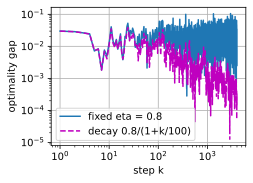

In [9]:
w_star = np.zeros(d)
for _ in range(4000):                         # full-batch reference optimum
    w_star = w_star - 0.5 * example_grads(w_star).mean(axis=0)
f_star = loss(w_star)

def sgd(schedule, steps=4000, b=8, seed=1):
    rg = np.random.default_rng(seed)
    w, gaps = np.zeros(d), []
    for k in range(steps):
        idx = rg.integers(0, n, size=b)
        s = 1 / (1 + np.exp(y[idx] * (X[idx] @ w)))
        g = (-(y[idx] * s)[:, None] * X[idx]).mean(axis=0) + lam_reg * w
        w = w - schedule(k) * g
        gaps.append(loss(w) - f_star)
    return np.array(gaps)

gap_fix = sgd(lambda k: 0.8)
gap_half = sgd(lambda k: 0.4)
gap_dec = sgd(lambda k: 0.8 / (1 + k / 100))
print(f'fixed eta = 0.8:     mean gap, last 1000 steps = {gap_fix[-1000:].mean():.2e}')
print(f'fixed eta = 0.4:     mean gap, last 1000 steps = {gap_half[-1000:].mean():.2e}')
print(f'decay 0.8/(1+k/100): mean gap, last 1000 steps = {gap_dec[-1000:].mean():.2e}')
d2l.plot(np.arange(1, 4001), [gap_fix, gap_dec], 'step k', 'optimality gap',
         xscale='log', yscale='log',
         legend=['fixed eta = 0.8', 'decay 0.8/(1+k/100)'])

The numbers land exactly where the theory points. Fixed $\eta = 0.8$ stalls at
an average gap of $2.3 \times 10^{-2}$; halving the step to $0.4$ halves the
floor to $1.1 \times 10^{-2}$: the linear-in-$\eta$ noise ball of
the equation, measured. The $1/k$ schedule, which spends its
early large steps crossing the valley and its late small steps shrinking the
ball, is at $5.7 \times 10^{-4}$ after the same $4000$ steps and still
descending as a power law, the straight line on the log-log plot. Modern
schedules (step decay, cosine, warmup; that section and
that section) are engineered refinements of exactly this
tradeoff, tuned for losses that are neither convex nor stationary. **Warmup**
(starting $\eta$ small and ramping it up) reads naturally in this
section's terms: at initialization the gradient noise is at its largest and,
per the edge-of-stability picture of that section,
the network has not yet adapted its curvature to the target step size, so
ramping $\eta$ gives the sharpness time to equilibrate instead of tripping
the stability ceiling in the first hundred steps. Schedules and warmup get
their full mathematical treatment in
that section.

### Coda: Why Not Newton?

Everything so far treats curvature as an obstacle: it caps the step size,
its spread $\kappa$ sets the iteration count, and momentum is a workaround.
Newton's
method flips the relationship and uses curvature as *information*. Minimize
the local quadratic model exactly (the $n$-dimensional version of
that section) by solving for its stationary point:

$$
\mathbf{x}_{k+1} = \mathbf{x}_k - \big(\nabla^2 f(\mathbf{x}_k)\big)^{-1} \nabla f(\mathbf{x}_k).
$$

On a quadratic $f(\mathbf{x}) = \tfrac12 \mathbf{x}^\top A \mathbf{x}$, the
model *is* the function, so one step lands exactly on the minimizer:
$\mathbf{x}_1 = \mathbf{x}_0 - A^{-1} A \mathbf{x}_0 = \mathbf{0}$, for every
$\kappa$. There is no condition number in Newton's world because the method is
**affine-invariant**: rescale or shear the coordinates,
$\mathbf{x} = T\mathbf{y}$, and Newton's iterates map through $T$ untouched
(Exercise 8): the warped valley and the round bowl are *the same problem*
to Newton, while gradient descent's behavior changes with every reparametrization.
Near a minimizer whose Hessian is positive definite and Lipschitz continuous
in a neighborhood, Newton started close enough converges
**quadratically**, $\|\mathbf{x}_{k+1} - \mathbf{x}^\star\| \le C\,\|\mathbf{x}_k - \mathbf{x}^\star\|^2$
(Theorem 3.5 of @Nocedal.Wright.2006): the number of correct digits
*doubles* per iteration. The cell shows both
facts: a one-step solve of the $\kappa = 100$ quadratic that costs gradient
descent $691$ iterations, and the doubling-digits signature on our logistic
toy.

In [10]:
A2 = np.diag([1.0, 100.0])                    # kappa = 100
x = np.array([1.0, 1.0])
x_new = x - np.linalg.solve(A2, A2 @ x)       # one Newton step
rate = (100 - 1) / (100 + 1)
print(f'Newton on the quadratic: |x_1| = {np.linalg.norm(x_new):.1e} after one step')
print(f'GD with the optimal step contracts by {rate:.4f} per step; it needs '
      f'{int(np.ceil(np.log(1e-6) / np.log(rate)))} steps for |x_k| <= 1e-6')
w = np.zeros(d)                               # Newton on the logistic loss
for it in range(6):
    s = 1 / (1 + np.exp(y * (X @ w)))
    g = example_grads(w).mean(axis=0)
    H = (X * (s * (1 - s))[:, None]).T @ X / n + lam_reg * np.eye(d)
    w = w - np.linalg.solve(H, g)
    print(f'Newton iteration {it + 1}:  |grad| = {np.linalg.norm(g):.1e}')
print('agrees with the SGD section optimum:', bool(np.allclose(w, w_star, atol=1e-8)))

Newton on the quadratic: |x_1| = 0.0e+00 after one step
GD with the optimal step contracts by 0.9802 per step; it needs 691 steps for |x_k| <= 1e-6
Newton iteration 1:  |grad| = 2.8e-01
Newton iteration 2:  |grad| = 3.2e-02
Newton iteration 3:  |grad| = 1.1e-03
Newton iteration 4:  |grad| = 1.2e-06
Newton iteration 5:  |grad| = 1.6e-12
Newton iteration 6:  |grad| = 3.1e-17
agrees with the SGD section optimum: True


The gradient norms fall as $2.8 \times 10^{-1}$, $3.2 \times 10^{-2}$,
$1.1 \times 10^{-3}$, $1.2 \times 10^{-6}$, $1.6 \times 10^{-12}$ (the
exponent roughly doubling each time, quadratic convergence visible to the
naked eye), and six iterations reproduce, to $10^{-8}$, the optimum that
$4000$ full-batch gradient steps computed in the previous cell.

So why does deep learning not use the method that ignores $\kappa$ and doubles
digits? Arithmetic. With $d$ parameters the Hessian has $d^2$ entries and the
Newton solve costs $O(d^3)$: at $d = 10^9$ that is $10^{18}$ entries (eight
exabytes in double precision) before the first of $\sim 10^{27}$ floating-point
operations (Exercise 8 asks you to put a year count on this). The objection is
structural too: away from a minimum the Hessian of a non-convex loss is
typically *indefinite*, and the Newton step, which seeks a stationary point
of the model, any stationary point, happily walks *toward* saddle points
unless safeguarded. What survives at scale is a family of cheaper curvature
surrogates. **L-BFGS** rebuilds a low-rank curvature estimate from recent
gradient differences with $O(d)$ memory [@Liu.Nocedal.1989], and the
adaptive family (AdaGrad [@Duchi.Hazan.Singer.2011], RMSProp
[@Tieleman.Hinton.2012], Adam [@Kingma.Ba.2014]) maintains a
*diagonal* preconditioner, a per-coordinate learning rate
(that section). Between the diagonal and the full matrix sit the
structured preconditioners that 2020s practice has made mainstream, **K-FAC**
[@Martens.Grosse.2015], **Shampoo** [@Gupta.Koren.Singer.2018], and
**Muon** [@Jordan.Jin.Boza.ea.2024], which exploit the fact that a
network's parameters come in *matrices* rather than one long vector.
First-order methods with curvature surrogates, fed by
minibatch gradients: that is the compromise this section has been deriving,
and it is what deep learning libraries ship. The mathematics of this family
is the subject of
that section.

### Quasi-Newton Methods: Curvature from Secants

The L-BFGS mention above hides an elegant idea. Newton asks the Hessian for a
local map from a step to a gradient change. A **quasi-Newton** method infers
that map from differences it has already observed. After moving by

$$
\mathbf s_k=\mathbf x_{k+1}-\mathbf x_k,
\qquad
\mathbf y_k=\nabla f(\mathbf x_{k+1})-\nabla f(\mathbf x_k),
$$

an inverse-Hessian approximation $H_{k+1}$ should satisfy the **secant
equation** $H_{k+1}\mathbf y_k=\mathbf s_k$. One vector equation cannot
determine a whole matrix, so BFGS chooses the symmetric rank-two update closest
to the previous approximation in a suitable matrix metric:

$$
H_{k+1}
=(I-\rho_k\mathbf s_k\mathbf y_k^\top)H_k
 (I-\rho_k\mathbf y_k\mathbf s_k^\top)
 +\rho_k\mathbf s_k\mathbf s_k^\top,
\qquad
\rho_k=(\mathbf y_k^\top\mathbf s_k)^{-1}.
$$

When $H_k$ is positive definite and the **curvature condition**
$\mathbf y_k^\top\mathbf s_k>0$ holds, the update remains positive definite,
so $-H_k\nabla f$ is a descent direction. A Wolfe line search is commonly used
because its conditions imply this positive-curvature test on a smooth
objective. On a strongly convex quadratic with exact line searches, BFGS
recovers the solution in at most $d$ iterations in exact arithmetic: each
secant pair identifies another curvature direction.

after d = 6 steps: BFGS 1.05e-14, GD 7.94e-01


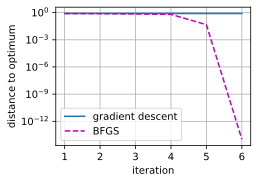

In [11]:
rng = np.random.default_rng(9)
d_bfgs = 6
Q, _ = np.linalg.qr(rng.standard_normal((d_bfgs, d_bfgs)))
A_bfgs = Q @ np.diag(np.geomspace(1., 1000., d_bfgs)) @ Q.T
b_bfgs = rng.standard_normal(d_bfgs)
x_star_bfgs = np.linalg.solve(A_bfgs, b_bfgs)
x_bfgs, H_bfgs = np.zeros(d_bfgs), np.eye(d_bfgs)
x_gd = np.zeros(d_bfgs)
eta_gd = 2 / (1 + 1000)                       # optimal fixed quadratic step
dist_bfgs, dist_gd = [], []
for k in range(d_bfgs):
    g = A_bfgs @ x_bfgs - b_bfgs
    p_bfgs = -H_bfgs @ g
    alpha = -(g @ p_bfgs) / (p_bfgs @ A_bfgs @ p_bfgs)  # exact line search
    step = alpha * p_bfgs
    y_diff = A_bfgs @ step
    rho = 1.0 / (y_diff @ step)
    V = np.eye(d_bfgs) - rho * np.outer(step, y_diff)
    H_bfgs = V @ H_bfgs @ V.T + rho * np.outer(step, step)
    x_bfgs += step
    x_gd -= eta_gd * (A_bfgs @ x_gd - b_bfgs)
    dist_bfgs.append(np.linalg.norm(x_bfgs - x_star_bfgs))
    dist_gd.append(np.linalg.norm(x_gd - x_star_bfgs))
d2l.plot(np.arange(1, d_bfgs + 1), [dist_gd, dist_bfgs],
         'iteration', 'distance to optimum',
         legend=['gradient descent', 'BFGS'], yscale='log')
print(f'after d = {d_bfgs} steps: BFGS {dist_bfgs[-1]:.2e}, '
      f'GD {dist_gd[-1]:.2e}')

The finite-termination property is an ideal quadratic benchmark, not a promise
for a neural loss. In general the line search is inexact, curvature changes,
and stochastic gradients corrupt $\mathbf y_k$. Full BFGS also stores a dense
$d\times d$ matrix. **L-BFGS** keeps only the most recent $m$ secant pairs and
applies the implied inverse by a two-loop recursion, reducing storage and work
to $O(md)$. This makes it attractive for deterministic medium-scale problems
and full-batch fine-tuning, but less natural when fresh minibatch noise makes
gradient differences unreliable.

### Trust Regions: Make the Model Earn Its Radius

Line search first chooses a direction and then decides how far to travel along
it. A **trust-region method** instead asks where the quadratic model is useful:

$$
\min_{\|\mathbf p\|\le\Delta_k}
 m_k(\mathbf p)
 =f(\mathbf x_k)+\nabla f(\mathbf x_k)^\top\mathbf p
  +\tfrac12\mathbf p^\top B_k\mathbf p.
$$

The radius $\Delta_k$ prevents an inaccurate local model from making an
arbitrarily large proposal and makes the subproblem bounded even when $B_k$ has
a negative eigenvalue. After approximately solving the subproblem, compare
actual with predicted improvement,

$$
r_k=
\frac{f(\mathbf x_k)-f(\mathbf x_k+\mathbf p_k)}
     {m_k(\mathbf 0)-m_k(\mathbf p_k)}.
$$

A ratio near one says the model predicted the step well, so accept it and
possibly enlarge the radius. A small or negative ratio rejects the step and
shrinks the radius. Thus the objective, not a fixed schedule, decides how much
of the curvature model to trust. Exact trust-region solves are unnecessary:
the dogleg method combines steepest descent with Newton on positive-definite
models, while truncated conjugate gradient stops at the boundary or upon
finding negative curvature using only Hessian--vector products
(that section).

Trust regions and quasi-Newton updates solve complementary problems. BFGS asks
how to estimate curvature without forming a Hessian; a trust region asks how
to safeguard whichever model we have. Neither displaces SGD for enormous
noisy objectives, but both are important for smaller deterministic models,
inner optimization problems, and understanding what “second order” means
beyond explicitly inverting a Hessian.

## Summary

* A direction $\mathbf{d}$ is a descent direction iff
  $\nabla f^\top \mathbf{d} < 0$; among unit directions the steepest is
  $-\nabla f / \|\nabla f\|$ by Cauchy--Schwarz. Descent directions form a
  half-space; gradient descent's choice is the greedy one, not the only one.
* $L$-smoothness erects a quadratic ceiling over the graph and yields the
  **descent lemma**: progress
  $\eta(1 - L\eta/2)\,\|\nabla f\|^2$ per step, positive for $\eta < 2/L$,
  best guaranteed at $\eta = 1/L$. Telescoping it gives
  $\min_k \|\nabla f(\mathbf{x}_k)\|^2 \le 2L(f(\mathbf{x}_0) - f^\star)/K$:
  stationarity at rate $O(1/K)$ with **no convexity**, a useful smooth-model
  benchmark for deep networks rather than a literal guarantee for nonsmooth
  architectures or trajectories without a finite smoothness bound. Backtracking line search achieves a
  step within a constant of $1/L$ without knowing $L$.
* On a quadratic, GD decouples into per-mode factors $1 - \eta\lambda_i$:
  stability demands $\eta < 2/L$, the optimal step
  $\eta^\star = 2/(\lambda_{\min} + \lambda_{\max})$ contracts by exactly
  $(\kappa - 1)/(\kappa + 1)$, and the cost of gradient descent is linear in
  $\kappa$. Real networks train *at* the $2/L$ boundary (the edge of
  stability) rather than safely below it.
* Convexity upgrades stationarity to global optimality: $O(1/k)$ values for
  smooth convex, linear rate $(1 - 1/\kappa)^k$ for strongly convex;
  stated here, proved in that section.
* Momentum turns each mode into a damped oscillator and improves the rate to
  $(\sqrt{\kappa} - 1)/(\sqrt{\kappa} + 1)$ on quadratics; Nesterov's
  look-ahead achieves $O(1/k^2)$ and $\sqrt{\kappa}$ dependence with a global
  guarantee, and these rates are *optimal* for first-order methods. Heavy
  ball's $\sqrt{\kappa}$ is quadratic-only: it can cycle on general
  strongly convex functions.
* Minibatch gradients are **unbiased** with variance
  $\mathrm{tr}\,\Sigma / b$; fixed-step SGD converges to a **noise ball** of
  squared radius $\approx \eta\sigma^2/(2\lambda)$, and Robbins--Monro decay
  ($\sum \eta_k = \infty$, $\sum \eta_k^2 < \infty$) trades the geometric rate
  for convergence that actually reaches the optimum.
* Newton's method is affine-invariant, immune to $\kappa$, and quadratically
  convergent, and costs $O(d^2)$ memory and $O(d^3)$ time per step. **BFGS**
  learns an inverse-Hessian approximation from secant pairs; **L-BFGS** stores
  only a short history. **Trust-region methods** bound the quadratic model's
  step and use actual-versus-predicted improvement to adjust that bound, making
  curvature useful without trusting it globally.

## Exercises

1. Prove the descent lemma the equation from
   $L$-smoothness without looking, and show that $\eta = 1/L$ maximizes the
   guaranteed per-step decrease $\eta(1 - L\eta/2)\,\|\nabla f\|^2$. What goes
   wrong in the bound (and in practice) at $\eta = 2/L$ exactly?
2. Show that $\mathbf{d} = -B\,\nabla f(\mathbf{x})$ is a descent direction
   for every positive definite matrix $B$. Then find the steepest descent
   direction when length is measured by the norm
   $\|\mathbf{d}\|_A = \sqrt{\mathbf{d}^\top A \mathbf{d}}$ for positive
   definite $A$, and recognize the answer as a *preconditioned* gradient:
   with $A = \nabla^2 f$, as Newton's direction. (*Hint:* substitute
   $\mathbf{u} = A^{1/2}\mathbf{d}$ and reuse Cauchy--Schwarz.)
3. Derive the optimal step $\eta^\star = 2/(\lambda_{\min} + \lambda_{\max})$
   by minimizing $\max_i |1 - \eta\lambda_i|$, confirm the contraction factor
   $(\kappa - 1)/(\kappa + 1)$, and explain geometrically why $\kappa \to 1$
   gives convergence in a single step.
4. On $f(\mathbf{x}) = \tfrac12(\lambda_1 x_1^2 + \lambda_2 x_2^2)$ with
   $\lambda_1 = 1$, $\lambda_2 = 10$, choose a step size with
   $2/\lambda_2 < \eta < 2/\lambda_1$ and run twenty iterations from
   $(1, 1)$. Verify that one coordinate converges while the other diverges,
   and reconcile this with the spectral-radius criterion of
   the equation.
5. Write heavy ball the equation on the one-dimensional
   quadratic $f(x) = \tfrac{\lambda}{2} x^2$ as a linear map of the state
   $(x_k, x_{k-1})$, and compute the eigenvalues of its $2 \times 2$ iteration
   matrix. Show that for $\beta \ge (1 - \sqrt{\eta\lambda})^2$ the
   eigenvalues are complex with modulus $\sqrt{\beta}$ (independent of
   $\lambda$), and conclude that the tuning
   the equation contracts *every* mode of a quadratic at rate
   $(\sqrt{\kappa}-1)/(\sqrt{\kappa}+1)$.
6. Prove the unbiasedness and $1/b$ variance of
   the equation. Now suppose the minibatch is drawn *without*
   replacement. Show the estimate is still unbiased, and that its covariance
   acquires the finite-population factor $\tfrac{N - b}{N - 1}$, so
   sampling without replacement is (slightly) better, and exact at $b = N$.
7. Use the equation to argue that *no* constant step size
   can converge to the minimizer while the gradient noise at the optimum is
   nonzero. Then study the tradeoff: combining the equation
   and the equation, the noise-ball radius scales like
   $\eta\sigma^2 / b$. Doubling $b$ doubles per-step compute and halves the
   ball; halving $\eta$ halves the ball for free but slows the transient.
   Discuss when large batches are worth it (hint: wall-clock time under data
   parallelism vs. total FLOPs), and check the prediction against the
   schedule-comparison experiment above, where halving $\eta$
   halved the measured floor.
8. Newton: show that on *any* strictly convex quadratic, the step
   the equation reaches the minimizer in one iteration
   regardless of $\kappa$. Show affine invariance: if $g(\mathbf{y}) = f(T\mathbf{y})$
   for invertible $T$, Newton iterates for $g$ satisfy
   $\mathbf{y}_k = T^{-1}\mathbf{x}_k$ where $\mathbf{x}_k$ are Newton
   iterates for $f$ (while gradient descent has no such property). Finally,
   estimate the time for one Newton solve at $d = 10^9$ on hardware doing
   $10^{15}$ FLOP/s, and conclude.
9. *Implicit bias.* Let $X \in \mathbb{R}^{n \times d}$ with $n < d$ and full
   row rank, and minimize the underdetermined least-squares loss
   $f(\mathbf{w}) = \tfrac12\|X\mathbf{w} - \mathbf{y}\|^2$, which has
   infinitely many global minimizers. Show that every gradient (hence,
   started from $\mathbf{w}_0 = \mathbf{0}$, every GD iterate) lies in the
   row space of $X$; show that the unique minimizer within the row space is
   the minimum-norm interpolator $\mathbf{w}^\dagger = X^\top (X X^\top)^{-1} \mathbf{y}$;
   and conclude that gradient descent with any fixed step size
   $0 < \eta < 2/\lambda_{\max}(X^\top X)$ converges to it. Moral: when
   minimizers
   are plentiful, the *optimizer*, not the loss, chooses among them, a
   theme that returns for deep networks in that section. (This
   exercise is deliberately pencil-and-paper; its numerical companion,
   watching the iterates land on $\mathbf{w}^\dagger$, is Exercise 8 of
   that section.)

10. **BFGS and the secant equation.** Verify directly that the update
    the equation is symmetric and satisfies
    $H_{k+1}\mathbf y_k=\mathbf s_k$. Show that it remains positive definite
    when $H_k\succ0$ and $\mathbf y_k^\top\mathbf s_k>0$.
11. **Trust-region acceptance.** For
    $f(x)=\tfrac14x^4-\tfrac12x^2$ at $x=0.2$, form the quadratic Taylor model.
    Solve the one-dimensional trust-region subproblem for several radii
    $\Delta$, compute the equation, and determine which
    proposals should be accepted. What goes wrong with the unrestricted Newton
    step at this point?

## Discussions

This section is the rate-and-condition-number justification for the main
book's optimization chapter: that section shows you gradient descent
running, that section and that section its stochastic
practice, that section and that section the optimizer zoo;
the descent lemma, the $\kappa$ and $\sqrt{\kappa}$ laws, the $1/b$
variance, and the noise ball proved here are the reasons those recipes work.
Within this part, the convexity that upgrades stationarity to optimality is
developed next in that section, constraints and duality follow
in that section, and the condition
number returns in its numerical role, measuring error amplification, in
that section.

[Discussions](https://d2l.discourse.group/t/gradient-based-optimization)